# Extra Feature Downloads: Neighbourhood + Elevation/Slope

Run this **after** `data_download.ipynb` and **before** modeling notebooks.

Downloads:
1. **Neighbourhood boundaries** (GeoJSON) — assigns each pavement segment to a Vancouver neighbourhood
2. **Elevation** (Open Topo Data API) — elevation in metres for each segment centroid
3. **Slope** (derived) — estimated from elevation differences between neighbouring segments

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/AI-FinalProject'
DATA_DIR = f'{PROJECT_ROOT}/data'

import os
print('Existing files:', sorted(os.listdir(DATA_DIR)))

Mounted at /content/drive
Existing files: ['311_service_requests.csv', '311_service_requests_2009_2021.csv', '311_service_requests_full.csv', 'city_project_package_street.csv', 'directional_traffic_count_locations.csv', 'intersection_traffic_movement_counts.csv', 'neighbourhood_boundaries.geojson', 'pavement_condition.csv', 'pavement_condition_major_road_network.csv', 'pavement_joined_features.csv', 'public_streets.csv', 'right_of_way_widths.csv', 'road_ahead_current_road_closures.csv', 'road_ahead_projects_under_construction.csv', 'road_ahead_upcoming_projects.csv', 'weather_vancouver.csv']


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
import time
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

---
## 1. Load Pavement Data

In [3]:
# Auto-detect separator
def load_csv(filename):
    path = f'{DATA_DIR}/{filename}'
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        first = f.readline()
    sep = ';' if first.count(';') > first.count(',') else ','
    return pd.read_csv(path, sep=sep, on_bad_lines='skip', low_memory=False)

df_pave = load_csv('pavement_condition.csv')
df_major = None
for fname in ['infrastructure_condition.csv', 'pavement_condition_major_road_network.csv']:
    if os.path.exists(f'{DATA_DIR}/{fname}'):
        df_major = load_csv(fname)
        break

df_pave['road_type'] = 'local'
if df_major is not None:
    df_major['road_type'] = 'major'
    df_pave = pd.concat([df_pave, df_major], ignore_index=True)

# Drop NO DATA
df_pave = df_pave[df_pave['PCI Rating'] != 'NO DATA'].reset_index(drop=True)

# Parse lat/lon from geo_point_2d
geo_str = df_pave['geo_point_2d'].astype(str)
if geo_str.iloc[0].startswith('{'):
    import ast
    parsed = geo_str.apply(lambda x: ast.literal_eval(x) if x != 'nan' else {})
    df_pave['lat'] = parsed.apply(lambda x: x.get('lat', np.nan))
    df_pave['lon'] = parsed.apply(lambda x: x.get('lon', np.nan))
else:
    parts = geo_str.str.split(',', expand=True)
    df_pave['lat'] = pd.to_numeric(parts[0], errors='coerce')
    df_pave['lon'] = pd.to_numeric(parts[1], errors='coerce')

df_pave = df_pave.dropna(subset=['lat', 'lon']).reset_index(drop=True)
print(f'Pavement segments with coordinates: {len(df_pave):,}')

Pavement segments with coordinates: 13,764


---
## 2. Neighbourhood Boundaries

In [4]:
# Download Vancouver neighbourhood boundaries GeoJSON
geojson_path = f'{DATA_DIR}/neighbourhood_boundaries.geojson'

if os.path.exists(geojson_path):
    print(f'Already exists: {geojson_path}')
else:
    url = 'https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/local-area-boundary/exports/geojson?lang=en&timezone=America%2FVancouver'
    print('Downloading neighbourhood boundaries...')
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with open(geojson_path, 'w') as f:
        f.write(r.text)
    print(f'Saved: {geojson_path} ({len(r.text)/1e6:.1f} MB)')

gdf_neighbourhoods = gpd.read_file(geojson_path)
print(f'Neighbourhoods: {len(gdf_neighbourhoods)}')

# Find name column
name_col = next((c for c in gdf_neighbourhoods.columns if 'name' in c.lower()), gdf_neighbourhoods.columns[0])
print(f'Name column: {name_col}')
print(gdf_neighbourhoods[name_col].tolist())

Already exists: /content/drive/MyDrive/AI-FinalProject/data/neighbourhood_boundaries.geojson
Neighbourhoods: 22
Name column: name
['Riley Park', 'Shaughnessy', 'Victoria-Fraserview', 'West Point Grey', 'Arbutus Ridge', 'Grandview-Woodland', 'Killarney', 'Strathcona', 'Sunset', 'Hastings-Sunrise', 'Kerrisdale', 'South Cambie', 'Downtown', 'Marpole', 'Oakridge', 'Dunbar-Southlands', 'Fairview', 'Mount Pleasant', 'Renfrew-Collingwood', 'West End', 'Kensington-Cedar Cottage', 'Kitsilano']


In [5]:
# Spatial join: assign neighbourhood to each pavement segment
pci_gdf = gpd.GeoDataFrame(
    df_pave,
    geometry=gpd.points_from_xy(df_pave['lon'], df_pave['lat']),
    crs='EPSG:4326'
)

pci_joined = gpd.sjoin(
    pci_gdf,
    gdf_neighbourhoods[[name_col, 'geometry']],
    how='left',
    predicate='within'
)

# Deduplicate: segments on neighbourhood boundaries match multiple polygons
pci_joined = pci_joined[~pci_joined.index.duplicated(keep='first')]
df_pave['neighbourhood'] = pci_joined[name_col].reindex(df_pave.index).values

matched = df_pave['neighbourhood'].notna().sum()
print(f'Matched: {matched:,} / {len(df_pave):,} ({matched/len(df_pave)*100:.1f}%)')
print(f'\nSegments per neighbourhood:')
print(df_pave['neighbourhood'].value_counts().to_string())

Matched: 13,693 / 13,764 (99.5%)

Segments per neighbourhood:
neighbourhood
Renfrew-Collingwood         1122
Kensington-Cedar Cottage    1075
Hastings-Sunrise            1035
Grandview-Woodland           776
Marpole                      774
Mount Pleasant               719
Kitsilano                    708
Sunset                       700
Victoria-Fraserview          656
Downtown                     634
Fairview                     577
Killarney                    565
Dunbar-Southlands            564
Kerrisdale                   556
Riley Park                   535
Shaughnessy                  534
Strathcona                   509
Oakridge                     480
West Point Grey              333
Arbutus Ridge                319
South Cambie                 280
West End                     242


---
## 3. Elevation (Open Topo Data API)

In [6]:
def get_elevations_batch(lats, lons, batch_size=100):
    """
    Fetch elevation from Open Topo Data API (free, no key needed).
    Returns elevation in metres. Rate limit: ~1 req/sec.
    """
    elevations = []
    total = len(lats)

    for i in range(0, total, batch_size):
        batch_lats = lats[i:i+batch_size]
        batch_lons = lons[i:i+batch_size]
        locations = '|'.join([f'{la},{lo}' for la, lo in zip(batch_lats, batch_lons)])

        try:
            r = requests.get(
                f'https://api.opentopodata.org/v1/srtm30m?locations={locations}',
                timeout=30
            )
            if r.status_code == 200:
                results = r.json().get('results', [])
                elevations.extend([res.get('elevation', np.nan) for res in results])
            else:
                elevations.extend([np.nan] * len(batch_lats))
                print(f'  Batch {i}: HTTP {r.status_code}')
        except Exception as e:
            elevations.extend([np.nan] * len(batch_lats))
            print(f'  Batch {i}: {e}')

        # Rate limiting
        time.sleep(1)

        if (i // batch_size) % 20 == 0:
            print(f'  Progress: {min(i+batch_size, total):,} / {total:,}')

    return elevations

In [7]:
# Check if elevation already computed
elev_path = f'{DATA_DIR}/pavement_elevation.csv'

if os.path.exists(elev_path):
    print(f'Loading cached elevations from {elev_path}')
    df_elev = pd.read_csv(elev_path)
    df_pave['elevation_m'] = df_elev['elevation_m'].values
else:
    print(f'Fetching elevation for {len(df_pave):,} segments...')
    print(f'Estimated time: ~{len(df_pave)//100} minutes')
    lats = df_pave['lat'].values
    lons = df_pave['lon'].values
    df_pave['elevation_m'] = get_elevations_batch(lats, lons)

    # Cache to disk
    df_pave[['lat', 'lon', 'elevation_m']].to_csv(elev_path, index=False)
    print(f'Saved: {elev_path}')

print(f'\nElevation stats:')
print(df_pave['elevation_m'].describe().round(1).to_string())
print(f'Missing: {df_pave["elevation_m"].isna().sum()}')

Fetching elevation for 13,764 segments...
Estimated time: ~137 minutes
  Progress: 100 / 13,764
  Progress: 2,100 / 13,764
  Progress: 4,100 / 13,764
  Progress: 6,100 / 13,764
  Progress: 8,100 / 13,764
  Progress: 10,100 / 13,764
  Progress: 12,100 / 13,764
Saved: /content/drive/MyDrive/AI-FinalProject/data/pavement_elevation.csv

Elevation stats:
count    13764.0
mean        52.5
std         29.9
min         -1.0
25%         27.0
50%         50.0
75%         78.0
max        128.0
Missing: 0


---
## 4. Slope Estimation

In [8]:
# Estimate slope using KD-Tree nearest neighbours
# For each segment, find 5 nearest neighbours, compute max elevation change / distance

coords = np.array(list(zip(df_pave['lat'], df_pave['lon'])))
elev = df_pave['elevation_m'].values

tree = cKDTree(coords)
distances, indices = tree.query(coords, k=6)  # self + 5 neighbours

slopes = []
for i in range(len(coords)):
    neighbour_idx = indices[i, 1:]   # skip self
    neighbour_dist = distances[i, 1:]
    neighbour_elev = elev[neighbour_idx]

    # Avoid division by zero
    valid = neighbour_dist > 0
    if valid.any() and not np.isnan(elev[i]):
        elev_diffs = np.abs(neighbour_elev[valid] - elev[i])
        # Convert degree distance to approximate metres (1 deg ~ 111km)
        dist_m = neighbour_dist[valid] * 111_000
        slope_pct = np.max(elev_diffs / dist_m) * 100
        slopes.append(slope_pct)
    else:
        slopes.append(np.nan)

df_pave['slope_pct'] = slopes

print('Slope stats (%):')
print(df_pave['slope_pct'].describe().round(2).to_string())
print(f'Missing: {df_pave["slope_pct"].isna().sum()}')

Slope stats (%):
count    13764.00
mean         5.49
std          3.88
min          0.00
25%          3.02
50%          4.57
75%          6.67
max         58.20
Missing: 0


---
## 5. Quick Validation

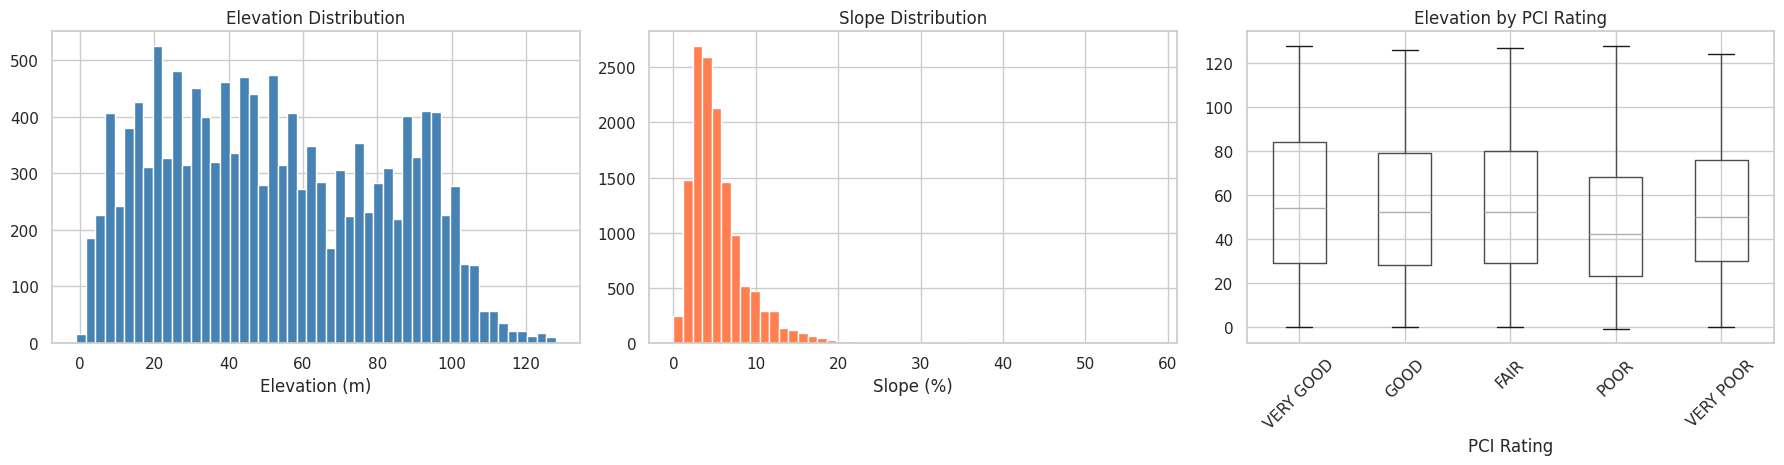

Mean elevation by PCI Rating:
PCI Rating
VERY GOOD    47.1
GOOD         53.6
FAIR         55.6
POOR         53.9
VERY POOR    53.1

Mean slope by PCI Rating:
PCI Rating
VERY GOOD    5.787
GOOD         5.395
FAIR         5.390
POOR         5.451
VERY POOR    5.389


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Elevation distribution
df_pave['elevation_m'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Elevation Distribution')
axes[0].set_xlabel('Elevation (m)')

# (b) Slope distribution
df_pave['slope_pct'].hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Slope Distribution')
axes[1].set_xlabel('Slope (%)')

# (c) Elevation by PCI Rating
order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
df_pave.boxplot(column='elevation_m', by='PCI Rating', ax=axes[2],
                positions=range(len(order)),
                showfliers=False)
axes[2].set_xticklabels(order, rotation=45)
axes[2].set_title('Elevation by PCI Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Correlation check
print('Mean elevation by PCI Rating:')
print(df_pave.groupby('PCI Rating')['elevation_m'].mean().reindex(order).round(1).to_string())
print(f'\nMean slope by PCI Rating:')
print(df_pave.groupby('PCI Rating')['slope_pct'].mean().reindex(order).round(3).to_string())

---
## 6. Export

In [10]:
# Save enriched pavement data with neighbourhood + elevation + slope
export_cols = ['Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating',
               'Year', 'road_type', 'lat', 'lon', 'neighbourhood', 'elevation_m', 'slope_pct']
# Keep only columns that exist
export_cols = [c for c in export_cols if c in df_pave.columns]

export_path = f'{DATA_DIR}/pavement_enriched.csv'
df_pave[export_cols].to_csv(export_path, index=False)
print(f'Exported: {export_path}')
print(f'Shape: {df_pave[export_cols].shape}')
print(f'Columns: {export_cols}')
print(f'\nSample:')
df_pave[export_cols].head()

Exported: /content/drive/MyDrive/AI-FinalProject/data/pavement_enriched.csv
Shape: (13764, 12)
Columns: ['Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating', 'Year', 'road_type', 'lat', 'lon', 'neighbourhood', 'elevation_m', 'slope_pct']

Sample:


,Road Name,From Street,To Street,length_(m),PCI Rating,Year,road_type,lat,lon,neighbourhood,elevation_m,slope_pct
0,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,2020,local,49.226375,-123.025350,Killarney,123.0,1.405451
1,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,2020,local,49.215083,-123.149834,Kerrisdale,34.0,5.764614
2,29TH AV,ELGIN ST,ROSS ST,101,POOR,2020,local,49.244606,-123.082029,Kensington-Cedar Cottage,70.0,3.571953
3,31ST AV,LANARK ST,DUMFRIES ST,93,VERY POOR,2020,local,49.243004,-123.074192,Kensington-Cedar Cottage,67.0,3.701658
4,53RD AV,KNIGHT ST,LANARK ST,100,VERY GOOD,2020,local,49.221790,-123.076733,Victoria-Fraserview,83.0,2.844605
